<a href="https://colab.research.google.com/github/arunrr2003/LLM/blob/main/DecoderLLM_Generative_IMDB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decoder-only LLM (Generative) Fine-tuning on IMDB (Colab)
This notebook:
- Uses a **pretrained decoder-only model** (`distilgpt2`).
- Fine-tunes it to **generate reviews conditioned on sentiment** (multi-token generation).
- Prints **tensor shapes** for key data structures (batch, logits, attentions).
- Includes a **minimal 2-block decoder Transformer** (teaching demo) with stored attention weights.


In [ ]:

# Install missing deps, only if needed, from code
import importlib, sys, subprocess

def ensure(pkg):
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "-q", "install", pkg])

ensure("datasets")
ensure("transformers")

# (peft is optional; this notebook fine-tunes without LoRA by default)


In [ ]:

# --- Imports
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


## 1) Load IMDB and make a train/valid split (20k/5k)

In [ ]:

ds = load_dataset("imdb")

# Split train (25k) -> train 20k + valid 5k, to mirror classic torchtext examples
split = ds["train"].train_test_split(test_size=5000, seed=42)
train_ds = split["train"]   # 20,000
valid_ds = split["test"]    # 5,000
test_ds  = ds["test"]       # 25,000

print("sizes:", len(train_ds), len(valid_ds), len(test_ds))
print("label set:", set(train_ds["label"]))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

sizes: 20000 5000 25000
label set: {0, 1}


## 2) Pretrained decoder-only model and tokenizer

In [ ]:

model_name = "distilgpt2"

tok = AutoTokenizer.from_pretrained(model_name)
# GPT-2 family usually has no pad token; set pad to EOS so we can batch with padding
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
model.config.pad_token_id = tok.pad_token_id

print("vocab_size:", tok.vocab_size, "pad_token_id:", tok.pad_token_id, "eos_token_id:", tok.eos_token_id)


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

vocab_size: 50257 pad_token_id: 50256 eos_token_id: 50256


## 3) Conditional generation format
We train the LM to generate **review text** given the sentiment.

Input format per example:
```
Sentiment: positive
Review: <full review text><eos>
```

In [ ]:

label_text = {0: "negative", 1: "positive"}

def format_conditional_review(text, label):
    # The model learns: (Sentiment prompt) -> generate the review tokens
    return f"Sentiment: {label_text[int(label)]}\nReview: {text}{tok.eos_token}"


## 4) Tokenization for causal LM training
- `input_ids`: `[T]`
- `attention_mask`: `[T]` (1=real token, 0=pad)
- `labels`: `[T]` (same as input_ids, but pad positions set to `-100` so they don't contribute to loss)


In [ ]:

MAX_LEN = 256  # good Colab compromise (IMDB reviews can be long)

def tokenize_causal(batch):
    texts = [format_conditional_review(t, y) for t, y in zip(batch["text"], batch["label"])]
    enc = tok(
        texts,
        truncation=True,
        max_length=MAX_LEN,
        padding="max_length",
    )
    labels = []
    for ids, am in zip(enc["input_ids"], enc["attention_mask"]):
        lab = ids.copy()
        # ignore loss on padding
        for j in range(len(lab)):
            if am[j] == 0:
                lab[j] = -100
        labels.append(lab)

    return {"input_ids": enc["input_ids"], "attention_mask": enc["attention_mask"], "labels": labels}

train_tok = train_ds.map(tokenize_causal, batched=True, remove_columns=train_ds.column_names).with_format("torch")
valid_tok = valid_ds.map(tokenize_causal, batched=True, remove_columns=valid_ds.column_names).with_format("torch")
test_tok  = test_ds.map(tokenize_causal,  batched=True, remove_columns=test_ds.column_names).with_format("torch")

print("One item tensor shapes:")
print("  input_ids     :", train_tok[0]['input_ids'].shape, train_tok[0]['input_ids'].dtype)        # [MAX_LEN]
print("  attention_mask:", train_tok[0]['attention_mask'].shape, train_tok[0]['attention_mask'].dtype) # [MAX_LEN]
print("  labels        :", train_tok[0]['labels'].shape, train_tok[0]['labels'].dtype)              # [MAX_LEN]


Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

One item tensor shapes:
  input_ids     : torch.Size([256]) torch.int64
  attention_mask: torch.Size([256]) torch.int64
  labels        : torch.Size([256]) torch.int64


## 5) DataLoader + collate (batch shapes)

In [ ]:

def collate_causal(batch):
    input_ids = torch.stack([x["input_ids"] for x in batch]).long()          # [B, T]
    attention_mask = torch.stack([x["attention_mask"] for x in batch]).long()# [B, T]
    labels = torch.stack([x["labels"] for x in batch]).long()                # [B, T]
    return input_ids, attention_mask, labels

BATCH_SIZE = 16

train_dl = DataLoader(train_tok, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_causal, num_workers=0)
valid_dl = DataLoader(valid_tok, batch_size=32, shuffle=False, collate_fn=collate_causal, num_workers=0)
test_dl  = DataLoader(test_tok,  batch_size=32, shuffle=False, collate_fn=collate_causal, num_workers=0)

# Show one batch shapes
ii, am, lab = next(iter(train_dl))
print("Batch shapes:")
print("  input_ids      :", ii.shape, ii.dtype)   # [B, T]
print("  attention_mask :", am.shape, am.dtype)   # [B, T]
print("  labels         :", lab.shape, lab.dtype) # [B, T]


Batch shapes:
  input_ids      : torch.Size([16, 256]) torch.int64
  attention_mask : torch.Size([16, 256]) torch.int64
  labels         : torch.Size([16, 256]) torch.int64


## 6) One forward pass with shape prints (logits + attentions)

In [ ]:
from transformers import AutoModelForCausalLM

# Re-load in eager mode (to allow output_attentions)
model_viz = AutoModelForCausalLM.from_pretrained(
    model_name,
    attn_implementation="eager"
).to(device)

model_viz.config.pad_token_id = tok.pad_token_id

# Load your fine-tuned weights (allow minor key differences)
model_viz.load_state_dict(model.state_dict(), strict=False)

# Move batch tensors to the same device
ii = ii.to(device, non_blocking=True)
am = am.to(device, non_blocking=True)

model_viz.eval()
with torch.no_grad():
    out = model_viz(input_ids=ii, attention_mask=am, output_attentions=True, use_cache=False)

print("logits:", out.logits.shape)
print("num layers:", len(out.attentions))
print("first attn shape:", out.attentions[0].shape)   # [B, heads, T, T]
print("last  attn shape:", out.attentions[-1].shape)

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


logits: torch.Size([16, 256, 50257])
num layers: 6
first attn shape: torch.Size([16, 12, 256, 256])
last  attn shape: torch.Size([16, 12, 256, 256])


## 7) Fine-tune (quick Colab demo)
This is a **true generative LM** objective (next-token prediction), not classification.

Tip: For a very fast demo, you can train on fewer examples by uncommenting the `select(...)` line.

In [ ]:

# Optional speed knob: train on fewer examples (fast demo)
# train_tok_small = train_tok.select(range(5000))
# train_dl = DataLoader(train_tok_small, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_causal, num_workers=0)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.01)
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

EPOCHS = 1
grad_accum = 2

def eval_lm_loss(dl, steps=100):
    model.eval()
    losses = []
    with torch.no_grad():
        for k, (ii, am, lab) in enumerate(dl):
            if k >= steps:
                break
            ii, am, lab = ii.to(device), am.to(device), lab.to(device)
            out = model(input_ids=ii, attention_mask=am, labels=lab)
            losses.append(out.loss.item())
    model.train()
    return float(np.mean(losses)) if losses else float("nan")

model.train()
for ep in range(1, EPOCHS + 1):
    running = 0.0
    for step, (ii, am, lab) in enumerate(train_dl, 1):
        ii = ii.to(device, non_blocking=True)
        am = am.to(device, non_blocking=True)
        lab = lab.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            out = model(input_ids=ii, attention_mask=am, labels=lab)
            loss = out.loss / grad_accum

        scaler.scale(loss).backward()

        if step % grad_accum == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        running += loss.item() * grad_accum

        if step % 200 == 0:
            val_loss = eval_lm_loss(valid_dl, steps=60)
            print(f"epoch {ep} step {step}/{len(train_dl)} train_loss {running/step:.4f} val_loss {val_loss:.4f}")

    val_loss = eval_lm_loss(valid_dl, steps=200)
    print(f"END epoch {ep}: train_loss {running/len(train_dl):.4f} val_loss {val_loss:.4f}")


/tmp/ipython-input-161282087.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
/tmp/ipython-input-161282087.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


epoch 1 step 200/1250 train_loss 3.8768 val_loss 3.6982
epoch 1 step 400/1250 train_loss 3.8438 val_loss 3.6752
epoch 1 step 600/1250 train_loss 3.8208 val_loss 3.6578
epoch 1 step 800/1250 train_loss 3.8077 val_loss 3.6421
epoch 1 step 1000/1250 train_loss 3.7962 val_loss 3.6297
epoch 1 step 1200/1250 train_loss 3.7878 val_loss 3.6216
END epoch 1: train_loss 3.7855 val_loss 3.6363


## 8) Generative demo (multi-token generation)
We now prompt with only `Sentiment: ...\nReview:` and let the model generate a full review.

In [ ]:

@torch.no_grad()
def generate_review(sentiment="positive", max_new_tokens=120, temperature=0.9, top_p=0.95):
    prompt = f"Sentiment: {sentiment}\nReview:"
    enc = tok(prompt, return_tensors="pt")
    input_ids = enc["input_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)

    gen = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=temperature,
        top_p=top_p,
        pad_token_id=tok.pad_token_id,
        eos_token_id=tok.eos_token_id,
    )
    return tok.decode(gen[0], skip_special_tokens=True)

print(generate_review("positive"))
print("----")
print(generate_review("negative"))


Sentiment: positive
Review: This is a great film to see. It was fun to see and I can't wait for a good film. The characters and the dialogue are funny, but they also have a lot of different qualities. The acting is funny and the direction is more believable. The storyline is funny and I wish they were filmed. The characters are funny and very natural and the story goes off the top of my top. Also the story really is fun and the story is interesting. The film was a great movie. If you have ever read the novel and are just a little disappointed you will enjoy watching it.
----
Sentiment: negative
Review: The best movie ever made.<br /><br />The movie was about a woman who was arrested for being a thief who had a problem with drugs and they have been sent to jail. She was arrested for selling her pills as a drug, but was released on bail. She was released on a $500,000 bond. She was arrested for selling drugs, which has a little. A couple of people in the audience saw this movie, and afte

## 9) Attention visualization (decoder self-attention)
We visualize attention (averaged over heads) for the **prompt-only** input.

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


T = 7 | Attn matrix shape: (7, 7)


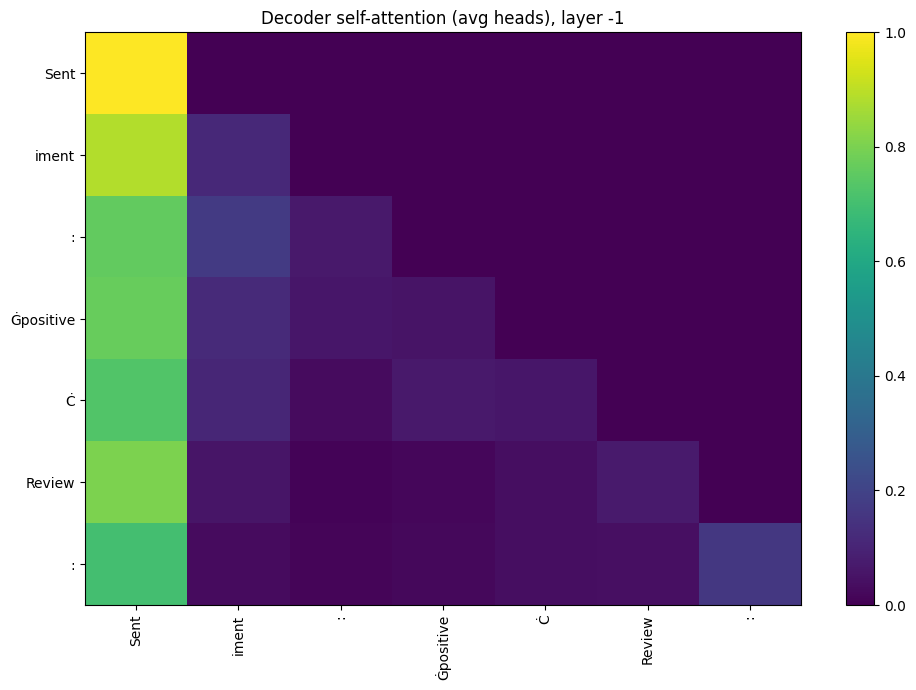

In [ ]:
from transformers import AutoModelForCausalLM

@torch.no_grad()
def show_decoder_attention(prompt, layer=-1, max_len=80, tok_limit=30):
    # --- build an eager-attention copy for visualization (supports output_attentions)
    model_viz = AutoModelForCausalLM.from_pretrained(
        model_name,
        attn_implementation="eager"
    ).to(device)
    model_viz.config.pad_token_id = tok.pad_token_id

    # load your fine-tuned weights; allow minor key diffs across impl/version
    model_viz.load_state_dict(model.state_dict(), strict=False)

    enc = tok(prompt, return_tensors="pt", truncation=True, max_length=max_len)
    input_ids = enc["input_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)

    out = model_viz(
        input_ids=input_ids,
        attention_mask=attention_mask,
        output_attentions=True,
        use_cache=False,
    )

    if out.attentions is None:
        raise RuntimeError("Attentions are still None. Ensure attn_implementation='eager' was used.")

    # attentions[layer]: [B, heads, T, T]
    A = out.attentions[layer][0].mean(dim=0).detach().cpu().numpy()  # [T, T]
    toks = tok.convert_ids_to_tokens(input_ids[0].detach().cpu().tolist())
    T = len(toks)
    T_plot = min(T, tok_limit)

    print("T =", T, "| Attn matrix shape:", A.shape)

    plt.figure(figsize=(10, 7))
    plt.imshow(A[:T_plot, :T_plot], aspect="auto")
    plt.colorbar()
    plt.xticks(range(T_plot), toks[:T_plot], rotation=90)
    plt.yticks(range(T_plot), toks[:T_plot])
    plt.title(f"Decoder self-attention (avg heads), layer {layer}")
    plt.tight_layout()
    plt.show()

show_decoder_attention("Sentiment: positive\nReview:", layer=-1, max_len=80, tok_limit=30)

## 10) A basic 2-block decoder-only Transformer (from scratch)
This mirrors "basic 2-block encoder" notebook but with:
- **causal mask**
- stored attention weights per block

We do a single forward pass on an existing batch to print shapes; training from scratch on IMDB is intentionally omitted here (it is slow and not the point of the demo).

In [ ]:

class SinusoidalPosEnc(nn.Module):
    def __init__(self, d_model, max_len=2048):
        super().__init__()
        pe = torch.zeros(max_len, d_model)                          # [Tmax, d_model]
        pos = torch.arange(0, max_len).float().unsqueeze(1)         # [Tmax, 1]
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))                 # [1, Tmax, d_model]

    def forward(self, x):
        T = x.size(1)
        return x + self.pe[:, :T, :]


class DecoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.drop1 = nn.Dropout(dropout)

        self.ln2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )
        self.drop2 = nn.Dropout(dropout)

        self.last_attn = None  # [B, heads, T, T]

    def forward(self, x, key_padding_mask=None, debug=False):
        B, T, D = x.shape
        if debug:
            print("  [Block] x:", x.shape)

        causal = torch.triu(torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1)  # [T,T]
        y = self.ln1(x)
        attn_out, attn_w = self.attn(
            y, y, y,
            attn_mask=causal,
            key_padding_mask=key_padding_mask,
            need_weights=True,
            average_attn_weights=False
        )
        self.last_attn = attn_w
        x = x + self.drop1(attn_out)

        y = self.ln2(x)
        ff_out = self.ff(y)
        x = x + self.drop2(ff_out)

        if debug:
            print("  [Block] attn_out:", attn_out.shape, "attn_w:", attn_w.shape, "ff_out:", ff_out.shape, "x_out:", x.shape)
        return x


class TinyDecoderLM(nn.Module):
    def __init__(self, vocab_size, d_model=128, n_heads=4, d_ff=256, n_layers=2, max_len=256, dropout=0.1, pad_id=tok.pad_token_id):
        super().__init__()
        self.pad_id = pad_id
        self.tok_emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.pos_enc = SinusoidalPosEnc(d_model, max_len=max_len)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([DecoderBlock(d_model, n_heads, d_ff, dropout=dropout) for _ in range(n_layers)])
        self.final_ln = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, input_ids, attention_mask=None, debug=False):
        # input_ids: [B,T]
        if debug:
            print("[TinyLM] input_ids:", input_ids.shape, input_ids.dtype)

        x = self.tok_emb(input_ids)    # [B,T,d_model]
        if debug:
            print("[TinyLM] tok_emb:", x.shape)

        x = self.pos_enc(x)
        x = self.drop(x)

        key_padding_mask = None
        if attention_mask is not None:
            key_padding_mask = (attention_mask == 0)  # [B,T] True at PADs
            if debug:
                print("[TinyLM] attention_mask:", attention_mask.shape, attention_mask.dtype,
                      "| key_padding_mask:", key_padding_mask.shape, key_padding_mask.dtype)

        for blk in self.blocks:
            x = blk(x, key_padding_mask=key_padding_mask, debug=debug)

        x = self.final_ln(x)
        logits = self.lm_head(x)        # [B,T,V]
        if debug:
            print("[TinyLM] logits:", logits.shape)
        return logits


tiny = TinyDecoderLM(vocab_size=tok.vocab_size, d_model=128, n_heads=4, d_ff=256, n_layers=2, max_len=MAX_LEN).to(device)

# Use a batch from earlier (ii, am) but ensure on device
ii2, am2, _ = next(iter(train_dl))
ii2, am2 = ii2.to(device), am2.to(device)

# Debug forward prints shapes
logits2 = tiny(ii2, attention_mask=am2, debug=True)

# Show stored attention shape from block 0
print("Stored attn shape (block0):", tiny.blocks[0].last_attn.shape)  # [B, heads, T, T]


[TinyLM] input_ids: torch.Size([16, 256]) torch.int64
[TinyLM] tok_emb: torch.Size([16, 256, 128])
[TinyLM] attention_mask: torch.Size([16, 256]) torch.int64 | key_padding_mask: torch.Size([16, 256]) torch.bool
  [Block] x: torch.Size([16, 256, 128])
  [Block] attn_out: torch.Size([16, 256, 128]) attn_w: torch.Size([16, 4, 256, 256]) ff_out: torch.Size([16, 256, 128]) x_out: torch.Size([16, 256, 128])
  [Block] x: torch.Size([16, 256, 128])
  [Block] attn_out: torch.Size([16, 256, 128]) attn_w: torch.Size([16, 4, 256, 256]) ff_out: torch.Size([16, 256, 128]) x_out: torch.Size([16, 256, 128])
[TinyLM] logits: torch.Size([16, 256, 50257])
Stored attn shape (block0): torch.Size([16, 4, 256, 256])


In [ ]:
import torch
import torch.nn as nn
import numpy as np

# 0) Instantiate tiny model (from your last block)
tiny = TinyDecoderLM(
    vocab_size=tok.vocab_size,
    d_model=128,
    n_heads=4,
    d_ff=256,
    n_layers=2,
    max_len=MAX_LEN,
    pad_id=tok.pad_token_id,
    dropout=0.1
).to(device)

# 1) Optimizer + (optional) AMP
optimizer = torch.optim.AdamW(tiny.parameters(), lr=3e-4, weight_decay=0.01)
use_amp = torch.cuda.is_available()
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

# 2) Loss: next-token prediction with ignore_index=-100 (your labels already set PAD to -100)
criterion = nn.CrossEntropyLoss(ignore_index=-100)

def lm_loss_from_logits(logits, labels):
    """
    logits: [B,T,V]
    labels: [B,T] with PAD positions = -100
    We do standard causal shift: predict labels[:,1:] from logits[:,:-1]
    """
    logits = logits[:, :-1, :].contiguous()   # [B,T-1,V]
    labels = labels[:, 1:].contiguous()       # [B,T-1]
    return criterion(logits.view(-1, logits.size(-1)), labels.view(-1))

@torch.no_grad()
def eval_lm_loss(dl, steps=100):
    tiny.eval()
    losses = []
    for k, (ii, am, lab) in enumerate(dl):
        if k >= steps:
            break
        ii, am, lab = ii.to(device), am.to(device), lab.to(device)
        logits = tiny(ii, attention_mask=am)
        loss = lm_loss_from_logits(logits, lab)
        losses.append(loss.item())
    tiny.train()
    return float(np.mean(losses)) if losses else float("nan")

# 3) Train loop
EPOCHS = 1
grad_accum = 2
max_grad_norm = 1.0

tiny.train()
optimizer.zero_grad(set_to_none=True)

for ep in range(1, EPOCHS + 1):
    running = 0.0

    for step, (ii, am, lab) in enumerate(train_dl, 1):
        ii = ii.to(device, non_blocking=True)
        am = am.to(device, non_blocking=True)
        lab = lab.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=use_amp):
            logits = tiny(ii, attention_mask=am)
            loss = lm_loss_from_logits(logits, lab) / grad_accum

        scaler.scale(loss).backward()

        if step % grad_accum == 0:
            # Unscale before clipping
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(tiny.parameters(), max_grad_norm)

            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        running += loss.item() * grad_accum

        if step % 200 == 0:
            val_loss = eval_lm_loss(valid_dl, steps=60)
            print(f"epoch {ep} step {step}/{len(train_dl)} train_loss {running/step:.4f} val_loss {val_loss:.4f}")

    val_loss = eval_lm_loss(valid_dl, steps=200)
    print(f"END epoch {ep}: train_loss {running/len(train_dl):.4f} val_loss {val_loss:.4f}")

# 4) (Optional) save weights
torch.save(tiny.state_dict(), "tiny_decoder_lm_imdb.pt")
print("saved -> tiny_decoder_lm_imdb.pt")

/tmp/ipython-input-2627118481.py:20: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/tmp/ipython-input-2627118481.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


epoch 1 step 200/1250 train_loss 8.7671 val_loss 7.1662
epoch 1 step 400/1250 train_loss 7.8592 val_loss 6.7344
epoch 1 step 600/1250 train_loss 7.4496 val_loss 6.4956
epoch 1 step 800/1250 train_loss 7.2020 val_loss 6.3244
epoch 1 step 1000/1250 train_loss 7.0242 val_loss 6.1921
epoch 1 step 1200/1250 train_loss 6.8879 val_loss 6.0936
END epoch 1: train_loss 6.8574 val_loss 6.0890
saved -> tiny_decoder_lm_imdb.pt


In [ ]:
import torch
import torch.nn.functional as F

@torch.no_grad()
def generate_tiny_decoder_lm(
    model,
    input_ids: torch.LongTensor,          # [B, T]
    attention_mask: torch.LongTensor=None, # [B, T] (1=keep, 0=pad). If None, inferred from pad_id.
    max_new_tokens: int = 50,
    eos_id: int = None,
    pad_id: int = 0,
    do_sample: bool = True,
    temperature: float = 1.0,
    top_k: int = 0,
    top_p: float = 1.0,
    repetition_penalty: float = 1.0,
):
    """
    Autoregressive generation for TinyDecoderLM (no cache).
    Returns: output_ids [B, T + max_new_tokens]
    """

    device = next(model.parameters()).device
    model.eval()

    input_ids = input_ids.to(device)

    if attention_mask is None:
        attention_mask = (input_ids != pad_id).long()
    else:
        attention_mask = attention_mask.to(device)

    B = input_ids.size(0)
    out = input_ids
    out_mask = attention_mask

    # Track which sequences have finished (hit EOS)
    finished = torch.zeros(B, dtype=torch.bool, device=device)

    def apply_repetition_penalty(logits, generated_ids, penalty):
        # logits: [B, V], generated_ids: [B, cur_len]
        if penalty == 1.0:
            return logits
        for b in range(logits.size(0)):
            if generated_ids.size(1) == 0:
                continue
            uniq = torch.unique(generated_ids[b])
            # From HF-style rep penalty:
            # if logit > 0 divide by penalty else multiply by penalty
            lb = logits[b, uniq]
            logits[b, uniq] = torch.where(lb > 0, lb / penalty, lb * penalty)
        return logits

    def top_k_top_p_filtering(logits, top_k=0, top_p=1.0):
        # logits: [B, V]
        if top_k and top_k > 0:
            vals, _ = torch.topk(logits, k=min(top_k, logits.size(-1)), dim=-1)
            kth = vals[:, -1].unsqueeze(-1)
            logits = torch.where(logits < kth, torch.full_like(logits, float("-inf")), logits)

        if top_p < 1.0:
            sorted_logits, sorted_idx = torch.sort(logits, descending=True, dim=-1)
            probs = F.softmax(sorted_logits, dim=-1)
            cumprobs = torch.cumsum(probs, dim=-1)

            # mask tokens whose cumulative prob exceeds top_p (keep at least 1)
            sorted_mask = cumprobs > top_p
            sorted_mask[:, 0] = False

            # scatter mask back
            mask = torch.zeros_like(logits, dtype=torch.bool)
            mask.scatter_(dim=-1, index=sorted_idx, src=sorted_mask)
            logits = logits.masked_fill(mask, float("-inf"))

        return logits

    for _ in range(max_new_tokens):
        # Forward on full context (no cache)
        logits_seq = model(out, attention_mask=out_mask)  # [B, L, V]
        logits = logits_seq[:, -1, :]                     # [B, V]

        # Avoid generating PAD for active sequences unless user explicitly wants it
        logits[:, pad_id] = float("-inf")

        # Repetition penalty
        logits = apply_repetition_penalty(logits, out, repetition_penalty)

        # Temperature
        if temperature is None or temperature <= 0:
            temperature = 1.0
        logits = logits / temperature

        if do_sample:
            # Top-k / Top-p
            logits_f = top_k_top_p_filtering(logits, top_k=top_k, top_p=top_p)
            probs = F.softmax(logits_f, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1).squeeze(1)  # [B]
        else:
            next_id = torch.argmax(logits, dim=-1)  # [B]

        # If eos_id is set, keep EOS once finished
        if eos_id is not None:
            next_id = torch.where(finished, torch.full_like(next_id, eos_id), next_id)
            finished = finished | (next_id == eos_id)

        # Append
        out = torch.cat([out, next_id.unsqueeze(1)], dim=1)
        out_mask = torch.cat([out_mask, torch.ones((B, 1), dtype=out_mask.dtype, device=device)], dim=1)

        # Stop early if all finished
        if eos_id is not None and torch.all(finished):
            break

    return out

# ---- Convenience wrapper for your tokenizer ----
def generate_text(
    model,
    tok,
    prompt: str,
    max_new_tokens=80,
    **gen_kwargs
):
    device = next(model.parameters()).device
    enc = tok(prompt, return_tensors="pt")
    input_ids = enc["input_ids"].to(device)
    attention_mask = enc.get("attention_mask", (input_ids != tok.pad_token_id).long()).to(device)

    out_ids = generate_tiny_decoder_lm(
        model,
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=max_new_tokens,
        eos_id=getattr(tok, "eos_token_id", None),
        pad_id=tok.pad_token_id,
        **gen_kwargs
    )
    return tok.decode(out_ids[0], skip_special_tokens=True)

# Example:
print(generate_text(tiny, tok, "Review: This movie was", do_sample=True, top_p=0.9, temperature=0.9, repetition_penalty=1.1))
print(generate_text(tiny, tok, "Review: This movie was", do_sample=False))  # greedy

Review: This movie was waiting, I'll, "" picture in the most than a little and it, such. It is. When too styles of all, but I am not way in to be day. <br /><br /> spin with a so "The film was just that's almost is people his doesn are just also are when it because for a pick you canman/ cause. That'so,
Review: This movie was a movie is a movie. The movie is a movie. The movie. I was a movie. I was a good. I was a good. I was a movie. I was a movie. I was a good. I was a movie. I was a movie. I was a movie. I was a movie. I was a very good. I was a good. I was a good
